## **Understnading the benefits of using LSTM over RNN**
With SimpleRNN we cannot learn or train the long tern dependencies due to vanishing gradient problem. In LSTM, we introduce a carry track to allow past information to be reinjected at a later time, thus fighting against the vanishing gradient problem.

## **Preparing the IMDB data**

In [ ]:
from keras.datasets import imdb
from keras.preprocessing import sequence
from keras.utils import pad_sequences

max_features = 20000 # Number of words to consider as features
maxlen = 1000 # Cuts off texts after this many words
batch_size = 64

print('Loading data...')
(input_train, y_train), (input_test, y_test) = imdb.load_data(num_words = max_features)

print(len(input_train), 'train_sequences')
print(len(input_test), 'test_sequences')

print('Pad sequences (samples x time)')
input_train = pad_sequences(input_train, maxlen = maxlen)
input_test = pad_sequences(input_test, maxlen = maxlen)

print('input train shape:', input_train.shape)
print('input test shape:', input_test.shape)

Loading data...
25000 train_sequences
25000 test_sequences
Pad sequences (samples x time)
input train shape: (25000, 1000)
input test shape: (25000, 1000)


## **Train the model with LSTM**

In [ ]:
# importing necessary layers to create an LSTM model
from keras.layers import LSTM
from keras.layers import Dense
from keras.models import Sequential
from keras.layers import Embedding

# design the model
model = Sequential()
model.add(Embedding(max_features, 32))
model.add(LSTM(32))
model.add(Dense(1, activation = 'sigmoid'))

# compile the model
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

#fit the data into the model and run it.
history = model.fit(input_train, y_train, epochs=10, batch_size=128, validation_split = 0.2)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - acc: 0.5758 - loss: 0.6645 - val_acc: 0.8092 - val_loss: 0.4463
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - acc: 0.8259 - loss: 0.4051 - val_acc: 0.8506 - val_loss: 0.3621
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - acc: 0.8702 - loss: 0.3240 - val_acc: 0.8504 - val_loss: 0.3547
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - acc: 0.8852 - loss: 0.2921 - val_acc: 0.8488 - val_loss: 0.3557
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - acc: 0.8911 - loss: 0.2774 - val_acc: 0.8718 - val_loss: 0.3014
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - acc: 0.9147 - loss: 0.2215 - val_acc: 0.8740 - val_loss: 0.2957
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - acc: 0.9216 - loss: 0.2026 - val_acc: 0.8588 - val_loss: 0.4744
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - acc: 0.9179 - loss: 0.2141 - val_acc: 0.8458 - val_loss: 0.3392
Epoch 9/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 

## **Plotting the results**

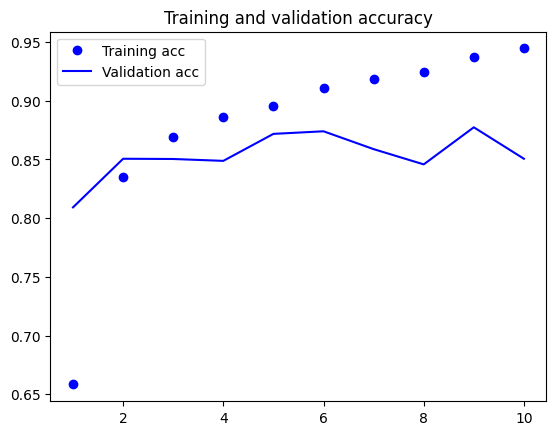

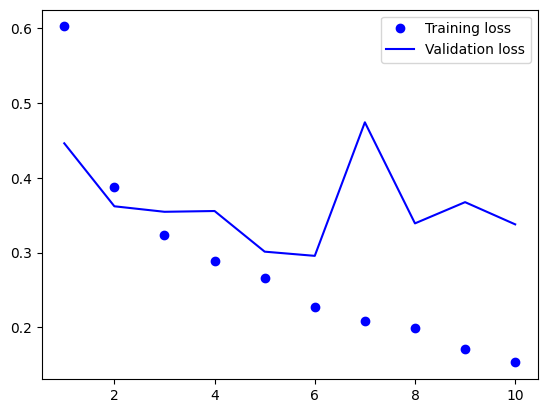

In [ ]:
import matplotlib.pyplot as plt
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs, acc, 'bo', label = 'Training acc')
plt.plot(epochs, val_acc, 'b', label = 'Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()

plt.plot(epochs, loss, 'bo', label = 'Training loss')
plt.plot(epochs, val_loss, 'b', label = 'Validation loss')
plt.legend()

plt.show()

## **Train the model with GRU**

In [ ]:
# importing necessary layers to create an LSTM model
from keras.layers import GRU
from keras.layers import Dense
from keras.models import Sequential
from keras.layers import Embedding

# design the model
model = Sequential()
model.add(Embedding(max_features, 32))
model.add(GRU(32))
model.add(Dense(1, activation = 'sigmoid'))

# compile the model
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

#fit the data into the model and run it.
history = model.fit(input_train, y_train, epochs=10, batch_size=128, validation_split = 0.2)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - acc: 0.5493 - loss: 0.6832 - val_acc: 0.7942 - val_loss: 0.4395
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - acc: 0.8008 - loss: 0.4294 - val_acc: 0.8336 - val_loss: 0.3828
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - acc: 0.8605 - loss: 0.3381 - val_acc: 0.8464 - val_loss: 0.3542
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - acc: 0.8890 - loss: 0.2799 - val_acc: 0.8504 - val_loss: 0.3521
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - acc: 0.8949 - loss: 0.2644 - val_acc: 0.7950 - val_loss: 0.4761
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - acc: 0.9077 - loss: 0.2331 - val_acc: 0.8818 - val_loss: 0.3122
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - acc: 0.9183 - loss: 0.2102 - val_acc: 0.8482 - val_loss: 0.3545
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - acc: 0.9271 - loss: 0.1932 - val_acc: 0.8786 - val_loss: 0.3418
Epoch 9/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 

## **Plotting the results**

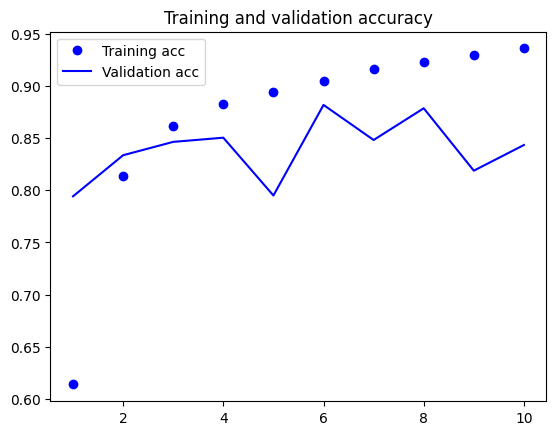

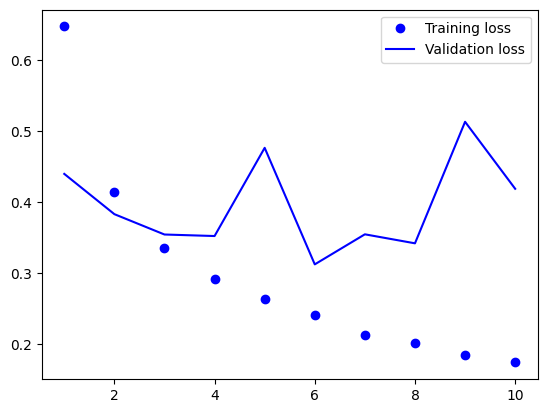

In [ ]:
import matplotlib.pyplot as plt
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs, acc, 'bo', label = 'Training acc')
plt.plot(epochs, val_acc, 'b', label = 'Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()

plt.plot(epochs, loss, 'bo', label = 'Training loss')
plt.plot(epochs, val_loss, 'b', label = 'Validation loss')
plt.legend()

plt.show()

Here GRU provide 5% better performance than GRU. That doesn't indicate that GRU is a better model than LSTM. We have to choose between these two models with rigorous experiments. Now Lets implement the same with pytorch.